## Imports

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Sample Data Overview

The dataset used in this analysis is sourced from "Introduction to Statistical Learning with Applications in R (ISLR)." It provides valuable insights into the relationship between advertising budgets and product sales.

**Data Description:**
- The dataset consists of observations for a particular product.
- It includes information on advertising budgets, measured in thousands of dollars, allocated to different media channels: TV, radio, and newspaper.
- The target variable is sales, also measured in thousands of units.

This dataset serves as a practical example to explore the impact of advertising spending in various media channels on product sales. It offers a real-world context to study advertising effectiveness and


In [98]:
df = pd.read_csv(r"/home/chunjielu/25sum/ML/dataset/Advertising.csv")

In [99]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [100]:
# Everything BUT the sales column
X = df.drop('sales',axis=1)

In [101]:
X

,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
...,...,...,...
195,38.2,3.7,13.8
196,94.2,4.9,8.1
197,177.0,9.3,6.4
198,283.6,42.0,66.2


In [102]:
y = df['sales']

In [103]:
y

0      22.1
1      10.4
2       9.3
3      18.5
4      12.9
       ... 
195     7.6
196     9.7
197    12.8
198    25.5
199    13.4
Name: sales, Length: 200, dtype: float64

## SciKit Learn 

---

## Polynomial Regression

## Polynomial Features Transformation

In our data preprocessing step, we'll utilize the `PolynomialFeatures` module to enhance our original dataset by introducing polynomial features. This transformation is particularly useful for expanding the feature space and capturing complex relationships between variables.

**Polynomial Transformation Overview:**
- Starting from a linear regression equation with a single feature, represented as:
  $$\hat{y} = \beta_0 + \beta_1x_1 + \epsilon$$

- We aim to create a polynomial regression equation by adding polynomial terms of the original feature, resulting in:
  $$\hat{y} = \beta_0 + \beta_1x_1 + \beta_1x_1^2 + \ldots + \beta_dx_1^d + \epsilon$$

- This transformation allows us to consider the effect of higher-degree polynomial features on the prediction. However, it's essential to carefully choose the degree (*d*) of the polynomial, which can impact model performance. Our evaluation metrics on the test set will guide us in this decision.

**Handling Multiple Features:**
- It's important to note that we typically have multiple features (*X*) in our dataset, not just a single feature as shown above.
- `PolynomialFeatures` can handle multiple features and will also take interaction terms into account.
- For instance, if our input samples are two-dimensional in the form [a, b], the degree-2 polynomial features will include terms like [1, a, b, a^2, ab, b^2], considering interactions between features.

This preprocessing step with polynomial features expansion allows us to capture more complex relationships between our variables, potentially enhancing the performance and flexibility of our regression model.


In [104]:
from sklearn.preprocessing import PolynomialFeatures

In [105]:
# Polynomial Features Transformation

# In this code snippet, we are initiating a polynomial feature transformation using the PolynomialFeatures module. 
# This transformation is part of our data preprocessing and is aimed at enriching our feature set with polynomial terms.

# from sklearn.preprocessing import PolynomialFeatures

# Explanation:
# - PolynomialFeatures is a utility provided by scikit-learn that allows us to create polynomial features from our original dataset.
# - The degree parameter is set to 2, indicating that we want to generate polynomial features up to the second degree.
#   - For example, if we have a feature x, this transformation will create new features like x^2, x^1, and x^0 (constant term).
# - The include_bias parameter is set to False, which means we won't include a bias or intercept term (i.e., a feature with all values set to 1) in the transformed dataset.

polynomial_converter = PolynomialFeatures(degree=3, include_bias=False)

# Why Polynomial Features?
# - By introducing polynomial features, we can capture nonlinear relationships between our original features and the target variable.
# - This is particularly useful when simple linear relationships are not sufficient to model the data accurately.
# - The choice of the degree (2 in this case) determines how many polynomial terms will be created. Higher degrees can capture more complex patterns but may also introduce complexity and the potential for overfitting.
# - After transforming the data, we can apply linear regression to the expanded feature set, effectively treating the polynomial terms as new features.

# This code sets up the polynomial feature transformation with a degree of 2, preparing our data for more flexible modeling that considers polynomial relationships between features and the target variable.


In [106]:
# Polynomial Features Transformation

# In this code snippet, we are applying the polynomial feature transformation to our original feature matrix X using the previously configured polynomial_converter.

# Applying Polynomial Features Transformation to X
poly_features = polynomial_converter.fit_transform(X)

# Explanation:
# - We've already set up the polynomial_converter using PolynomialFeatures with a degree of 2.
# - Now, we're using the fit_transform method to apply this transformation to our original feature matrix X.
# - The result, stored in poly_features, will contain the original features along with their polynomial combinations up to the second degree, as specified.

# Why Apply Polynomial Features?
# - The transformation allows us to capture nonlinear relationships between the original features and the target variable.
# - It expands the feature space to include polynomial terms, which can be important when linear relationships are insufficient for modeling the data.
# - The expanded feature set, represented by poly_features, can be used as input for a linear regression model, effectively considering these polynomial terms as new features.

# This code step prepares our data with polynomial features, enhancing its ability to represent complex patterns in our regression analysis.


In [107]:
poly_features.shape

(200, 19)

In [108]:
X.shape

(200, 3)

In [109]:
X.iloc[0]

TV           230.1
radio         37.8
newspaper     69.2
Name: 0, dtype: float64

In [110]:
poly_features[0]

array([2.30100000e+02, 3.78000000e+01, 6.92000000e+01, 5.29460100e+04,
       8.69778000e+03, 1.59229200e+04, 1.42884000e+03, 2.61576000e+03,
       4.78864000e+03, 1.21828769e+07, 2.00135918e+06, 3.66386389e+06,
       3.28776084e+05, 6.01886376e+05, 1.10186606e+06, 5.40101520e+04,
       9.88757280e+04, 1.81010592e+05, 3.31373888e+05])

In [111]:
poly_features[0][:3]

array([230.1,  37.8,  69.2])

In [112]:
poly_features[0][:3]**2

array([52946.01,  1428.84,  4788.64])

The interaction terms $$x_1  \cdot x_2 \text{  and  } x_1  \cdot x_3 \text{  and  }   x_2  \cdot x_3 $$

In [113]:
230.1*37.8

8697.779999999999

In [114]:
230.1*69.2

15922.92

In [115]:
37.8*69.2

2615.7599999999998

## Train | Test Split

Make sure you have watched the Machine Learning Overview videos on Supervised Learning to understand why we do this step

In [116]:
from sklearn.model_selection import train_test_split

In [117]:
# random_state: 
# https://stackoverflow.com/questions/28064634/random-state-pseudo-random-number-in-scikit-learn
X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)

### Model for fitting on Polynomial Data

#### Create an instance of the model with parameters

In [118]:
from sklearn.linear_model import LinearRegression

In [119]:


# Configuring Linear Regression Model
# - We are using the LinearRegression class from scikit-learn.
# - The fit_intercept parameter is set to True, which means the model will estimate an intercept (bias) term in addition to the coefficients for the features.
#   - When fit_intercept is True, the model will fit a line that does not necessarily pass through the origin (0,0). It can have a non-zero intercept.

model = LinearRegression(fit_intercept=True)

# Explanation:
# - The LinearRegression class is a commonly used linear regression model in scikit-learn.
# - By setting fit_intercept to True, we indicate that the model should consider an intercept term in addition to the coefficients for the features.
# - The intercept term allows the linear regression line to have an offset from the origin (0,0), which can be crucial when the data does not naturally pass through the origin.

# Including the intercept term is often appropriate in real-world scenarios where the relationship between the independent and dependent variables may have an offset or baseline value.

# This code initializes our linear regression model, ready to be trained on the polynomial features and target variable.


In [120]:
print(X_train.shape)

(140, 19)


### Fit/Train the Model on the training data

**Make sure you only fit to the training data, in order to fairly evaluate your model's performance on future data**

In [121]:
model.fit(X_train,y_train)

LinearRegression()


-----

## Evaluation on the Test Set

### Calculate Performance on Test Set

We want to fairly evaluate our model, so we get performance metrics on the test set (data the model has never seen before).

In [122]:
test_predictions = model.predict(X_test)

In [123]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [124]:
MAE = mean_absolute_error(y_test,test_predictions)
MSE = mean_squared_error(y_test,test_predictions)
RMSE = np.sqrt(MSE)

In [125]:
MAE
#1.2

0.4127516085409412

In [126]:
MSE
#2.3

0.3367813797596327

In [127]:
RMSE
#1.5

0.5803286825236477

In [128]:
df['sales'].mean()

14.0225

### Comparison with Simple Linear Regression

**Results on the Test Set (Note: Use the same Random Split to fairly compare!)**

* Simple Linear Regression:
    * MAE: 1.213
    * RMSE: 1.516

* Polynomial 2-degree:
    * MAE: 0.4896
    * RMSE: 0.664

## Choosing a Model: Adjusting Parameters

Once we've built our initial polynomial regression model, the question arises: are we satisfied with its performance? It's possible that increasing the polynomial order might lead to even better performance, but we must exercise caution to avoid overfitting.

### The Exploration Process

To explore the impact of polynomial order and address the question of model complexity, we'll engage in a systematic process. We'll use a for loop to:

1. Create different order polynomial features for our data.
2. Split these polynomial features into training and test sets.
3. Fit a polynomial regression model on the training data.
4. Evaluate and report performance metrics on both the training and test results.
5. Visualize these results to gain insights into the concept of overfitting.

This iterative approach will help us understand the trade-off between model complexity and performance. We'll consider whether a higher-order polynomial is justified or if it leads to overfitting—a scenario where the model fits the training data too closely but struggles to generalize to unseen data.

The process will guide us in selecting an appropriate model, considering factors like bias-variance trade-off and model generalization. It's a crucial step in building a reliable and robust regression model.


In [129]:
# TRAINING ERROR PER DEGREE
train_rmse_errors = []

# TEST ERROR PER DEGREE
test_rmse_errors = []




# Iterating through different polynomial degrees
for d in range(1, 10):
    
    # CREATE POLY DATA SET FOR DEGREE "d"
    # Initialize the PolynomialFeatures converter to create polynomial features of degree 'd' from the original features.
    polynomial_converter = PolynomialFeatures(degree=d, include_bias=False)
    poly_features = polynomial_converter.fit_transform(X)
    
    # SPLIT THIS NEW POLY DATA SET
    # Split the polynomial feature set into training and test sets.
    X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)
    
    # TRAIN ON THIS NEW POLY SET
    # Initialize a Linear Regression model and fit it to the training data.
    model = LinearRegression(fit_intercept=True)
    model.fit(X_train, y_train)
    
    # PREDICT ON BOTH TRAIN AND TEST
    # Make predictions using the trained model on both the training and test data.
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    # Calculate Errors
    
    # Errors on Train Set
    # Calculate the root mean squared error (RMSE) for the training predictions.
    train_RMSE = np.sqrt(mean_squared_error(y_train, train_pred))
    
    # Errors on Test Set
    # Calculate the RMSE for the test predictions.
    test_RMSE = np.sqrt(mean_squared_error(y_test, test_pred))

    # Append errors to lists for plotting later
    # Store the calculated RMSE values in lists for both the training and test sets.
    train_rmse_errors.append(train_RMSE)
    test_rmse_errors.append(test_RMSE)


In [130]:
test_rmse_errors

[1.5161519375993877,
 0.6646431757269272,
 0.5803286825236477,
 0.5077742639859423,
 2.5758223594965215,
 4.316970101683667,
 1379.5215240812513,
 3977.7095180347496,
 95072.84363768557]

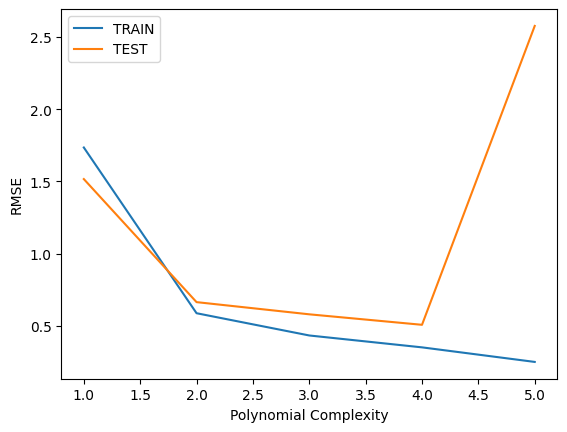

In [131]:
plt.plot(range(1,6),train_rmse_errors[:5],label='TRAIN')
plt.plot(range(1,6),test_rmse_errors[:5],label='TEST')
plt.xlabel("Polynomial Complexity")
plt.ylabel("RMSE")
plt.legend()

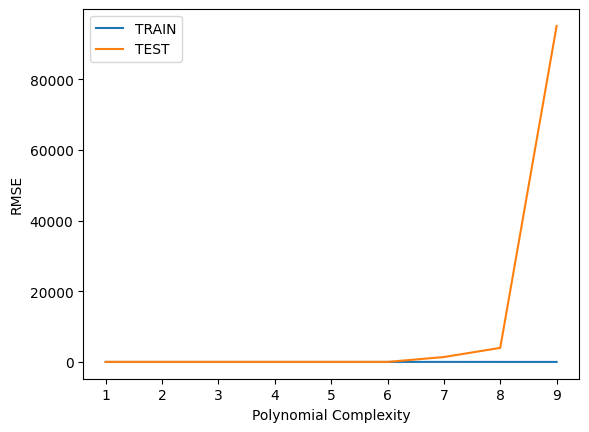

In [132]:
plt.plot(range(1,10),train_rmse_errors,label='TRAIN')
plt.plot(range(1,10),test_rmse_errors,label='TEST')
plt.xlabel("Polynomial Complexity")
plt.ylabel("RMSE")
plt.legend()

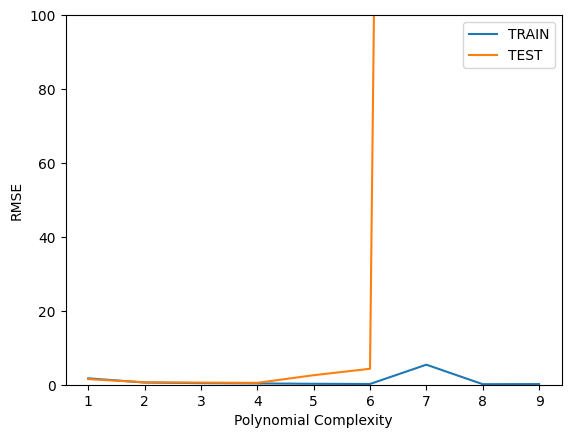

In [133]:
plt.plot(range(1,10),train_rmse_errors,label='TRAIN')
plt.plot(range(1,10),test_rmse_errors,label='TEST')
plt.xlabel("Polynomial Complexity")
plt.ylabel("RMSE")
plt.ylim(0,100)
plt.legend()

## Finalizing Model Choice

Having explored various polynomial degrees and evaluated model performance, we're now ready to finalize our choice of model. This involves saving two essential components: the Polynomial Feature creator and the trained model itself. Here's the process for proceeding:

### Steps for Finalizing the Model:

1. **Choose Final Parameters based on Test Metrics:**
   - Review the test metrics, such as RMSE, for different polynomial degrees.
   - Select the degree that provides the best balance between model complexity and performance on unseen data.

2. **Retrain on All Data:**
   - After selecting the optimal polynomial degree, retrain the chosen model on the entire dataset.
   - This step ensures that the model is trained on the full dataset, maximizing its predictive capabilities.

3. **Save Polynomial Converter Object:**
   - Save the `PolynomialFeatures` object that was used to create polynomial features from the original dataset.
   - This object is essential for transforming new data in the same way as the training data.

4. **Save Model:**
   - Save the trained linear regression model itself.
   - This allows for easy deployment and use in making predictions on new data.

By following these steps, we ensure that we have a well-tuned and deployable model ready for practical use. The saved components enable us to maintain consistency in data preprocessing and apply the model to make predictions in real-world scenarios.


In [134]:
# Based on our chart, could have also been degree=4, but 
# it is better to be on the safe side of complexity
final_poly_converter = PolynomialFeatures(degree=3,include_bias=False)

In [135]:
final_model = LinearRegression()

In [136]:
final_model.fit(final_poly_converter.fit_transform(X),y)

LinearRegression()

### Saving Model and Converter

In [137]:
from joblib import dump, load

In [138]:
dump(final_model, 'sales_poly_model.joblib') 

['sales_poly_model.joblib']

In [139]:
dump(final_poly_converter,'poly_converter.joblib')

['poly_converter.joblib']

## Deployment and Predictions

### Prediction on New Data

Recall that we will need to **convert** any incoming data to polynomial data, since that is what our model is trained on. We simply load up our saved converter object and only call **.transform()** on the new data, since we're not refitting to a new data set.

**Our next ad campaign will have a total spend of 149k on TV, 22k on Radio, and 12k on Newspaper Ads, how many units could we expect to sell as a result of this?**

In [140]:
loaded_poly = load('poly_converter.joblib')
loaded_model = load('sales_poly_model.joblib')

In [141]:
campaign = [[149,22,12]]

In [142]:
campaign_poly = loaded_poly.transform(campaign)

/home/chunjielu/.local/lib/python3.10/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [143]:
campaign_poly

array([[1.490000e+02, 2.200000e+01, 1.200000e+01, 2.220100e+04,
        3.278000e+03, 1.788000e+03, 4.840000e+02, 2.640000e+02,
        1.440000e+02, 3.307949e+06, 4.884220e+05, 2.664120e+05,
        7.211600e+04, 3.933600e+04, 2.145600e+04, 1.064800e+04,
        5.808000e+03, 3.168000e+03, 1.728000e+03]])

In [144]:
final_model.predict(campaign_poly)

array([14.64501014])

-----
---